          STUDENT PERFORMANCE ML ANALYSIS


Saving Day18_19_student_habits_performance.csv to Day18_19_student_habits_performance.csv

Dataset loaded successfully!
File: Day18_19_student_habits_performance.csv
Shape: (1000, 16)

First 5 rows:
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No

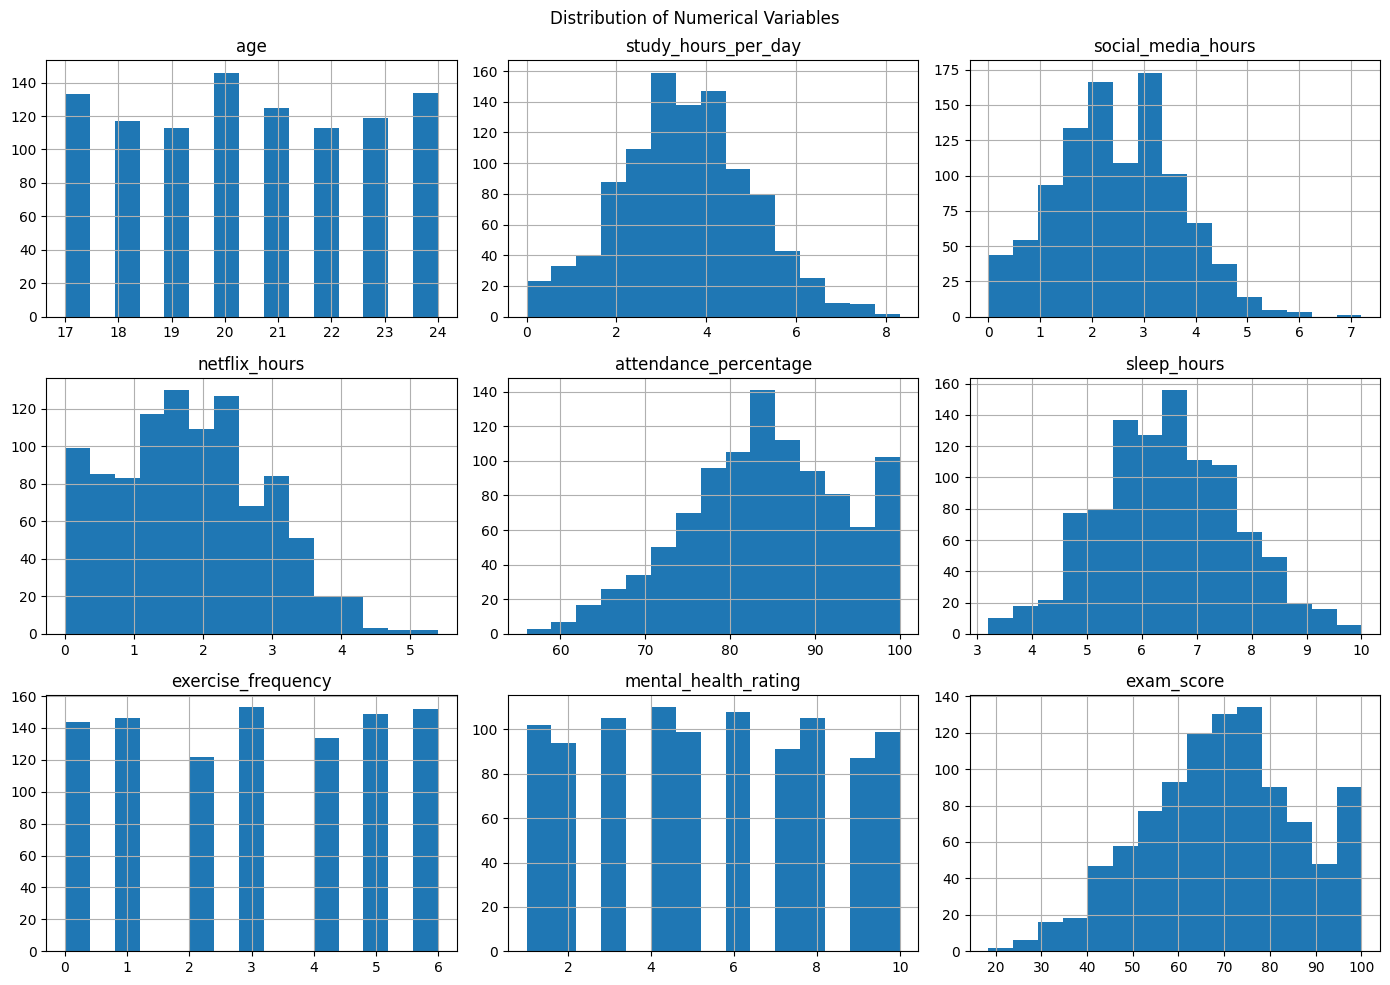


2. CORRELATION ANALYSIS

Correlation with exam_score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


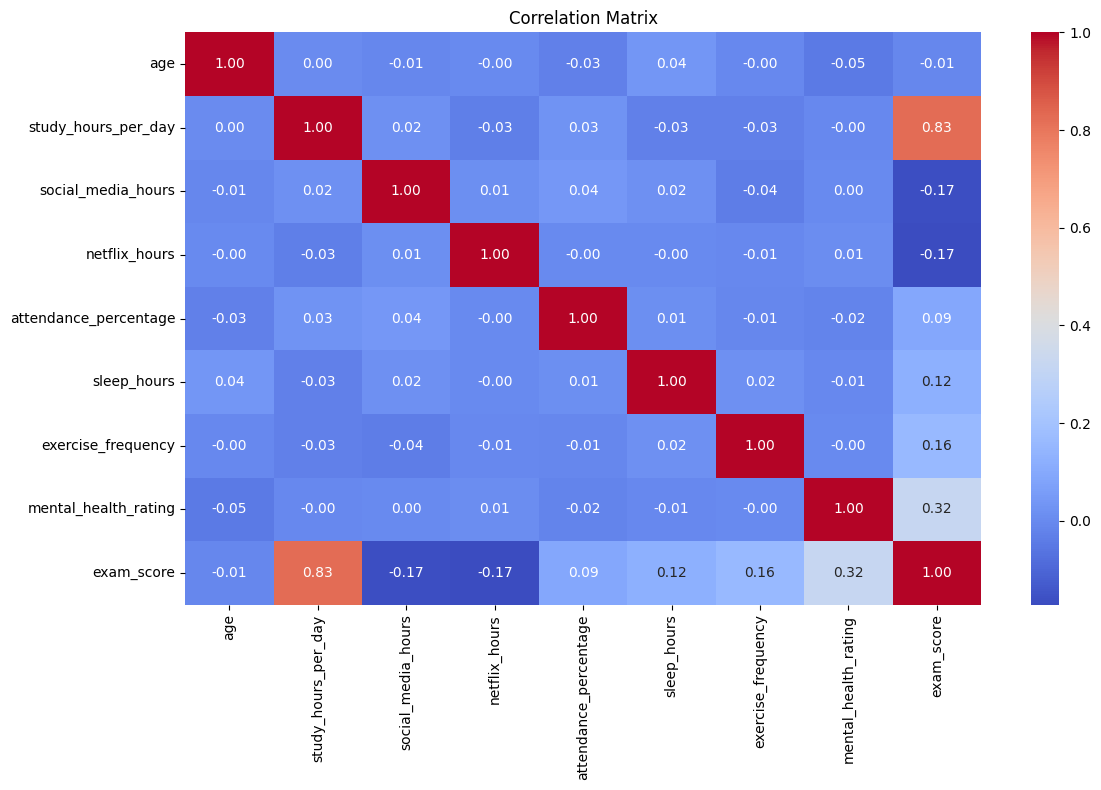


3. RELATIONSHIPS WITH EXAM SCORE


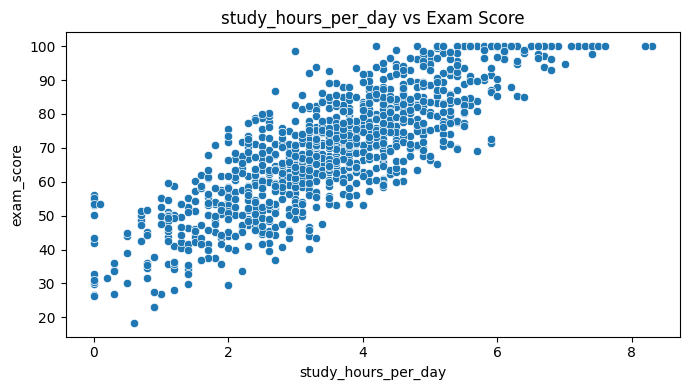

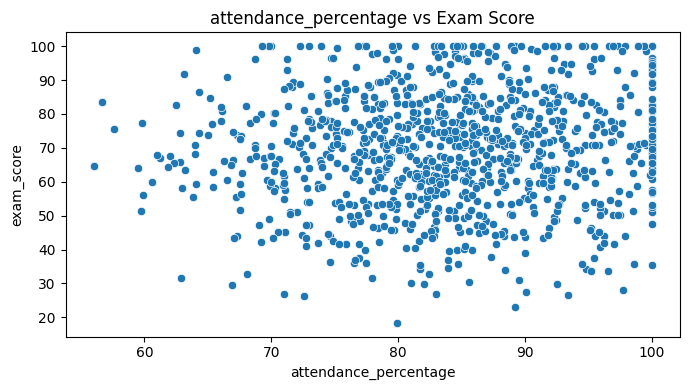

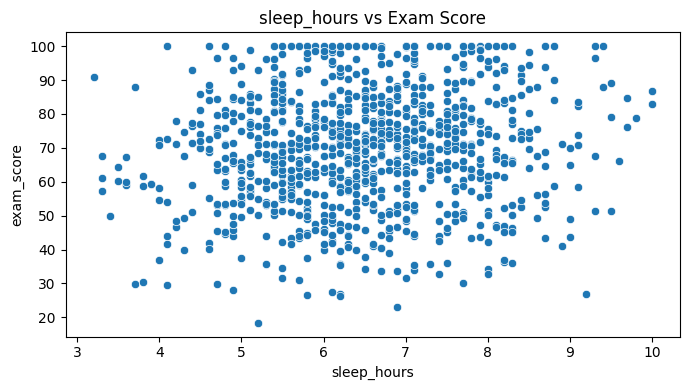

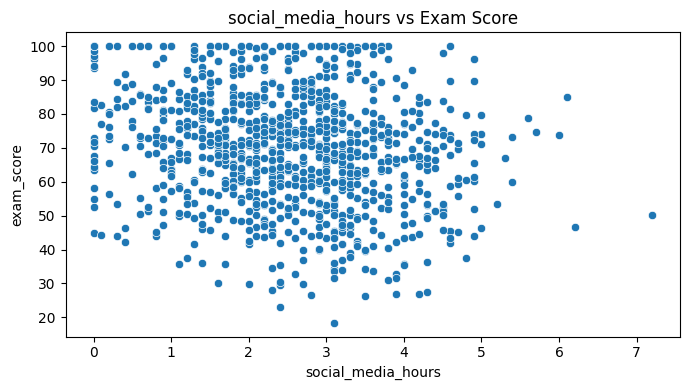


4. OUTLIER CHECK
age: 0 potential outliers
study_hours_per_day: 7 potential outliers
social_media_hours: 5 potential outliers
netflix_hours: 4 potential outliers
attendance_percentage: 3 potential outliers
sleep_hours: 2 potential outliers
exercise_frequency: 0 potential outliers
mental_health_rating: 0 potential outliers
exam_score: 2 potential outliers

5. DATA PREPARATION
Features:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']

Target: exam_score

Numerical Features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical Features:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_q

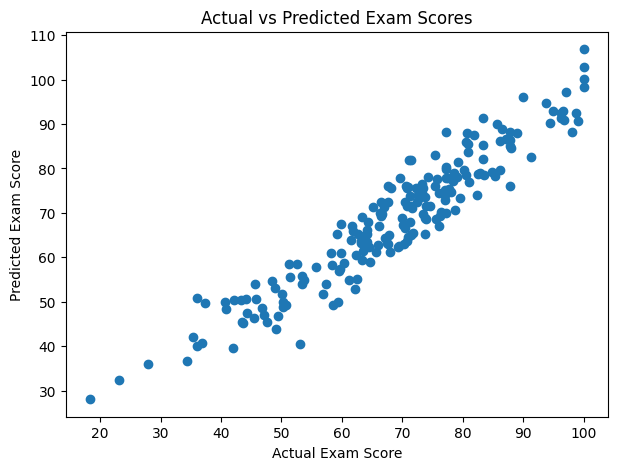


7. CLASSIFICATION PROBLEM
result
Pass    869
Fail    131
Name: count, dtype: int64

Classification Results:
Training Accuracy : 0.98
Testing Accuracy  : 0.95
Precision         : 0.97
Recall            : 0.98
F1-Score          : 0.97

Confusion Matrix:
[[ 21   5]
 [  4 170]]


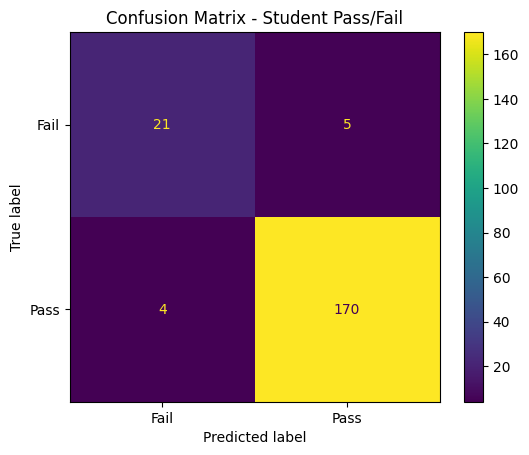


8. MODEL PERFORMANCE COMPARISON

Regression:
Training R²: 1.00
Testing R² : 0.90

Classification:
Training Accuracy: 0.98
Testing Accuracy : 0.95

Interpretation:
Regression does not show strong signs of overfitting.
Classification does not show strong signs of overfitting.

9. IMPORTANT FINDINGS

Variables most related to exam_score:
study_hours_per_day     0.825419
mental_health_rating    0.321523
netflix_hours          -0.171779
social_media_hours     -0.166733
exercise_frequency      0.160107
Name: exam_score, dtype: float64

10. FIVE KEY INSIGHTS

1. The dataset contains 1000 student records, and the
   analysis uses exam_score as the regression target.

2. The variable most strongly related to exam_score is
   'study_hours_per_day', with a correlation of 0.83.

3. The Linear Regression model achieved a testing R² of
   0.90, showing how much variation in exam scores
   is explained by the selected features.

4. The classification model achieved a testing accuracy of
   0.95 for 

In [1]:
# DAY 18 & 19 - STUDENT PERFORMANCE ML ANALYSIS
# Regression + Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 65)
print("          STUDENT PERFORMANCE ML ANALYSIS")
print("=" * 65)


# ============================================================
# 1. LOAD DATASET
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")
print("File:", file_name)
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n" + "=" * 65)
print("1. EXPLORATORY DATA ANALYSIS")
print("=" * 65)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe(include="all"))


# ============================================================
# 3. NUMERICAL DATA DISTRIBUTION
# ============================================================

numeric = df.select_dtypes(include=np.number).columns

df[numeric].hist(
    figsize=(14, 10),
    bins=15
)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()


# ============================================================
# 4. CORRELATION WITH EXAM SCORE
# ============================================================

print("\n" + "=" * 65)
print("2. CORRELATION ANALYSIS")
print("=" * 65)

correlation = df[numeric].corr()

print("\nCorrelation with exam_score:")
print(
    correlation["exam_score"]
    .sort_values(ascending=False)
)


plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 5. EXAM SCORE RELATIONSHIPS
# ============================================================

print("\n" + "=" * 65)
print("3. RELATIONSHIPS WITH EXAM SCORE")
print("=" * 65)

features_to_plot = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours"
]

for feature in features_to_plot:

    if feature in df.columns:

        plt.figure(figsize=(7, 4))

        sns.scatterplot(
            data=df,
            x=feature,
            y="exam_score"
        )

        plt.title(f"{feature} vs Exam Score")
        plt.tight_layout()
        plt.show()


# ============================================================
# 6. OUTLIER CHECK
# ============================================================

print("\n" + "=" * 65)
print("4. OUTLIER CHECK")
print("=" * 65)

for column in numeric:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[column] < lower) | (df[column] > upper)).sum()

    print(f"{column}: {count} potential outliers")


# ============================================================
# 7. PREPARE FEATURES AND TARGET
# ============================================================

print("\n" + "=" * 65)
print("5. DATA PREPARATION")
print("=" * 65)

# Remove duplicate records
df = df.drop_duplicates()

# Target for regression
X = df.drop(columns=["exam_score"])
y = df["exam_score"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: exam_score")


# ============================================================
# 8. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))


# ============================================================
# 10. PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# ============================================================
# 11. LINEAR REGRESSION
# ============================================================

print("\n" + "=" * 65)
print("6. LINEAR REGRESSION")
print("=" * 65)

regression_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

# Fit ONLY on training data
regression_model.fit(X_train, y_train)

# Predictions
train_prediction = regression_model.predict(X_train)
test_prediction = regression_model.predict(X_test)


# ============================================================
# 12. REGRESSION EVALUATION
# ============================================================

train_mae = mean_absolute_error(
    y_train,
    train_prediction
)

test_mae = mean_absolute_error(
    y_test,
    test_prediction
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_prediction
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_prediction
    )
)

train_r2 = r2_score(
    y_train,
    train_prediction
)

test_r2 = r2_score(
    y_test,
    test_prediction
)

print("\nRegression Results:")
print(f"Training MAE  : {train_mae:.2f}")
print(f"Testing MAE   : {test_mae:.2f}")
print(f"Training RMSE : {train_rmse:.2f}")
print(f"Testing RMSE  : {test_rmse:.2f}")
print(f"Training R²   : {train_r2:.2f}")
print(f"Testing R²    : {test_r2:.2f}")


# ============================================================
# 13. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    test_prediction
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()


# ============================================================
# 14. CREATE PASS / FAIL TARGET
# ============================================================

print("\n" + "=" * 65)
print("7. CLASSIFICATION PROBLEM")
print("=" * 65)

# 50 or above = Pass
df["result"] = np.where(
    df["exam_score"] >= 50,
    "Pass",
    "Fail"
)

print(df["result"].value_counts())


# ============================================================
# 15. PREPARE CLASSIFICATION DATA
# ============================================================

X_class = df.drop(
    columns=["exam_score", "result"]
)

y_class = df["result"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)


# ============================================================
# 16. LOGISTIC REGRESSION
# ============================================================

classification_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

# Fit ONLY on training data
classification_model.fit(
    X_train_c,
    y_train_c
)

# Predictions
train_class_prediction = classification_model.predict(
    X_train_c
)

test_class_prediction = classification_model.predict(
    X_test_c
)


# ============================================================
# 17. CLASSIFICATION EVALUATION
# ============================================================

train_accuracy = accuracy_score(
    y_train_c,
    train_class_prediction
)

test_accuracy = accuracy_score(
    y_test_c,
    test_class_prediction
)

test_precision = precision_score(
    y_test_c,
    test_class_prediction,
    pos_label="Pass"
)

test_recall = recall_score(
    y_test_c,
    test_class_prediction,
    pos_label="Pass"
)

test_f1 = f1_score(
    y_test_c,
    test_class_prediction,
    pos_label="Pass"
)

print("\nClassification Results:")
print(f"Training Accuracy : {train_accuracy:.2f}")
print(f"Testing Accuracy  : {test_accuracy:.2f}")
print(f"Precision         : {test_precision:.2f}")
print(f"Recall            : {test_recall:.2f}")
print(f"F1-Score          : {test_f1:.2f}")


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test_c,
    test_class_prediction,
    labels=["Fail", "Pass"]
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot()

plt.title("Confusion Matrix - Student Pass/Fail")
plt.show()


# ============================================================
# 19. OVERFITTING / UNDERFITTING CHECK
# ============================================================

print("\n" + "=" * 65)
print("8. MODEL PERFORMANCE COMPARISON")
print("=" * 65)

print("\nRegression:")
print(f"Training R²: {train_r2:.2f}")
print(f"Testing R² : {test_r2:.2f}")

print("\nClassification:")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy : {test_accuracy:.2f}")

regression_gap = train_r2 - test_r2
classification_gap = train_accuracy - test_accuracy

print("\nInterpretation:")

if regression_gap > 0.15:
    print("Regression shows possible overfitting.")
elif test_r2 < 0.50:
    print("Regression may be underfitting.")
else:
    print("Regression does not show strong signs of overfitting.")

if classification_gap > 0.15:
    print("Classification shows possible overfitting.")
else:
    print("Classification does not show strong signs of overfitting.")


# ============================================================
# 20. TOP CORRELATIONS WITH EXAM SCORE
# ============================================================

print("\n" + "=" * 65)
print("9. IMPORTANT FINDINGS")
print("=" * 65)

score_correlations = (
    correlation["exam_score"]
    .drop("exam_score")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nVariables most related to exam_score:")
print(score_correlations.head(5))


# ============================================================
# 21. FIVE DATA-DRIVEN INSIGHTS
# ============================================================

print("\n" + "=" * 65)
print("10. FIVE KEY INSIGHTS")
print("=" * 65)

top_factor = score_correlations.index[0]
top_correlation = score_correlations.iloc[0]

print(f"""
1. The dataset contains {len(df)} student records, and the
   analysis uses exam_score as the regression target.

2. The variable most strongly related to exam_score is
   '{top_factor}', with a correlation of {top_correlation:.2f}.

3. The Linear Regression model achieved a testing R² of
   {test_r2:.2f}, showing how much variation in exam scores
   is explained by the selected features.

4. The classification model achieved a testing accuracy of
   {test_accuracy:.2f} for predicting whether a student
   passes or fails using 50 as the threshold.

5. The difference between training and testing performance
   was examined to determine whether the models show signs
   of overfitting or underfitting.
""")

print("\n" + "=" * 65)
print("             ANALYSIS COMPLETED")
print("=" * 65)